In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

print("✅ Semua library berhasil diimport")
print(f"Pandas version: {pd.__version__}")
print(f"Sklearn version: {__import__('sklearn').__version__}")

✅ Semua library berhasil diimport
Pandas version: 3.0.2
Sklearn version: 1.8.0


In [2]:
import os

DATASET_PATH = os.path.expanduser("~/blueteam-monitor/ml-engine/datasets/cicids")

# Load file yang paling relevan untuk project kita
files = {
    "monday_normal":   "Monday-WorkingHours.pcap_ISCX.csv",
    "tuesday_brute":   "Tuesday-WorkingHours.pcap_ISCX.csv",
    "friday_portscan": "Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv",
    "friday_ddos":     "Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv",
}

dfs = {}
for key, filename in files.items():
    path = os.path.join(DATASET_PATH, filename)
    print(f"Loading {filename}...")
    dfs[key] = pd.read_csv(path, low_memory=False)
    print(f"  → {dfs[key].shape[0]:,} rows, {dfs[key].shape[1]} columns")

print("\n✅ Semua file berhasil dimuat")

Loading Monday-WorkingHours.pcap_ISCX.csv...
  → 529,918 rows, 79 columns
Loading Tuesday-WorkingHours.pcap_ISCX.csv...
  → 445,909 rows, 79 columns
Loading Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv...
  → 286,467 rows, 79 columns
Loading Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv...
  → 225,745 rows, 79 columns

✅ Semua file berhasil dimuat


In [3]:
# Lihat struktur data
df_sample = dfs["tuesday_brute"]

print("=== KOLOM DATASET ===")
print(df_sample.columns.tolist())

print("\n=== 3 BARIS PERTAMA ===")
df_sample.head(3)

=== KOLOM DATASET ===
[' Destination Port', ' Flow Duration', ' Total Fwd Packets', ' Total Backward Packets', 'Total Length of Fwd Packets', ' Total Length of Bwd Packets', ' Fwd Packet Length Max', ' Fwd Packet Length Min', ' Fwd Packet Length Mean', ' Fwd Packet Length Std', 'Bwd Packet Length Max', ' Bwd Packet Length Min', ' Bwd Packet Length Mean', ' Bwd Packet Length Std', 'Flow Bytes/s', ' Flow Packets/s', ' Flow IAT Mean', ' Flow IAT Std', ' Flow IAT Max', ' Flow IAT Min', 'Fwd IAT Total', ' Fwd IAT Mean', ' Fwd IAT Std', ' Fwd IAT Max', ' Fwd IAT Min', 'Bwd IAT Total', ' Bwd IAT Mean', ' Bwd IAT Std', ' Bwd IAT Max', ' Bwd IAT Min', 'Fwd PSH Flags', ' Bwd PSH Flags', ' Fwd URG Flags', ' Bwd URG Flags', ' Fwd Header Length', ' Bwd Header Length', 'Fwd Packets/s', ' Bwd Packets/s', ' Min Packet Length', ' Max Packet Length', ' Packet Length Mean', ' Packet Length Std', ' Packet Length Variance', 'FIN Flag Count', ' SYN Flag Count', ' RST Flag Count', ' PSH Flag Count', ' ACK Fl

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,88,640,7,4,440,358,220,0,62.857143,107.349008,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,88,900,9,4,600,2944,300,0,66.666667,132.287566,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,88,1205,7,4,2776,2830,1388,0,396.571429,677.274651,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


In [4]:
print("=== DISTRIBUSI LABEL PER FILE ===\n")

for key, df in dfs.items():
    # Kolom label biasanya ' Label' (ada spasi di depan)
    label_col = [c for c in df.columns if 'label' in c.lower()][0]
    print(f"📁 {key} | kolom label: '{label_col}'")
    print(df[label_col].value_counts())
    print()

=== DISTRIBUSI LABEL PER FILE ===

📁 monday_normal | kolom label: ' Label'
 Label
BENIGN    529918
Name: count, dtype: int64

📁 tuesday_brute | kolom label: ' Label'
 Label
BENIGN         432074
FTP-Patator      7938
SSH-Patator      5897
Name: count, dtype: int64

📁 friday_portscan | kolom label: ' Label'
 Label
PortScan    158930
BENIGN      127537
Name: count, dtype: int64

📁 friday_ddos | kolom label: ' Label'
 Label
DDoS      128027
BENIGN     97718
Name: count, dtype: int64



In [5]:
# Gabungkan semua dataframe
df_all = pd.concat(dfs.values(), ignore_index=True)

# Bersihkan nama kolom (hapus spasi di depan)
df_all.columns = df_all.columns.str.strip()

print(f"Total rows: {df_all.shape[0]:,}")
print(f"Total kolom: {df_all.shape[1]}")

# Cek distribusi label keseluruhan
print("\n=== DISTRIBUSI LABEL KESELURUHAN ===")
print(df_all['Label'].value_counts())
print(f"\nTotal BENIGN  : {(df_all['Label'] == 'BENIGN').sum():,}")
print(f"Total ATTACK  : {(df_all['Label'] != 'BENIGN').sum():,}")


Total rows: 1,488,039
Total kolom: 79

=== DISTRIBUSI LABEL KESELURUHAN ===
Label
BENIGN         1187247
PortScan        158930
DDoS            128027
FTP-Patator       7938
SSH-Patator       5897
Name: count, dtype: int64

Total BENIGN  : 1,187,247
Total ATTACK  : 300,792


In [6]:
print("=== CEK MISSING VALUES ===")
missing = df_all.isnull().sum()
print(f"Kolom dengan missing values: {(missing > 0).sum()}")
print(missing[missing > 0])

print("\n=== CEK NILAI INF ===")
numeric_cols = df_all.select_dtypes(include=[np.number]).columns
inf_count = np.isinf(df_all[numeric_cols]).sum().sum()
print(f"Total nilai infinite: {inf_count:,}")

print("\n=== CEK DUPLIKAT ===")
dup = df_all.duplicated().sum()
print(f"Total baris duplikat: {dup:,}")

=== CEK MISSING VALUES ===
Kolom dengan missing values: 1
Flow Bytes/s    284
dtype: int64

=== CEK NILAI INF ===
Total nilai infinite: 1,928

=== CEK DUPLIKAT ===
Total baris duplikat: 132,430


In [7]:
df_clean = df_all.copy()

# Hapus duplikat
df_clean = df_clean.drop_duplicates()

# Ganti nilai inf dengan NaN lalu drop
df_clean[numeric_cols] = df_clean[numeric_cols].replace([np.inf, -np.inf], np.nan)
df_clean = df_clean.dropna()

# Buat kolom label binary: 0 = normal, 1 = attack
df_clean['is_attack'] = (df_clean['Label'] != 'BENIGN').astype(int)

print(f"Rows setelah cleaning: {df_clean.shape[0]:,}")
print(f"\nDistribusi final:")
print(f"  BENIGN (0): {(df_clean['is_attack'] == 0).sum():,}")
print(f"  ATTACK (1): {(df_clean['is_attack'] == 1).sum():,}")
print(f"\n✅ Data siap untuk training")

Rows setelah cleaning: 1,354,703

Distribusi final:
  BENIGN (0): 1,126,845
  ATTACK (1): 227,858

✅ Data siap untuk training


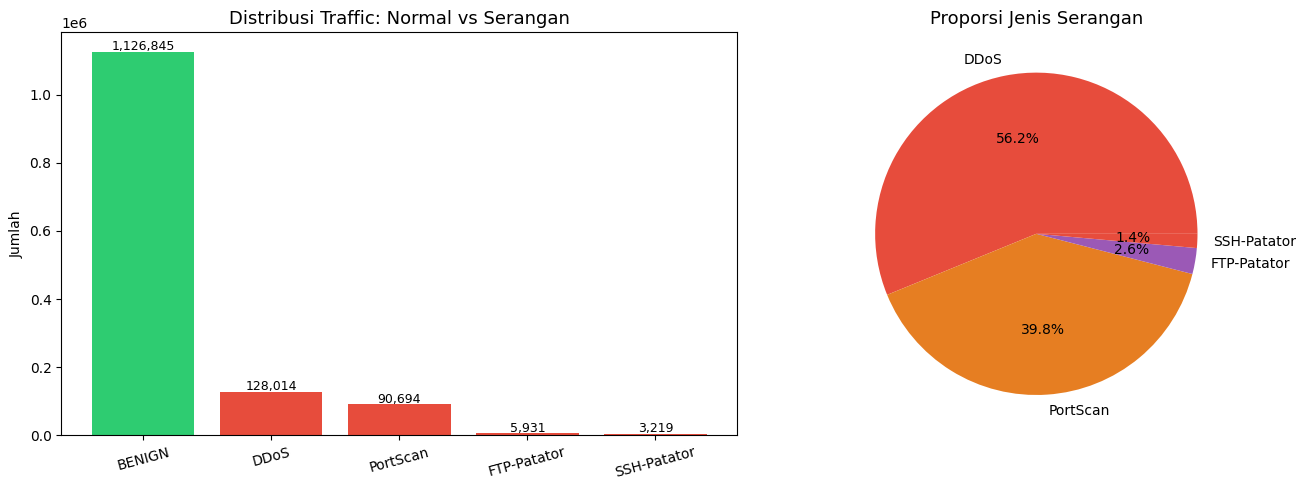

✅ Plot tersimpan: distribusi_serangan.png


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Distribusi label
attack_counts = df_clean['Label'].value_counts()
colors = ['#2ecc71' if l == 'BENIGN' else '#e74c3c' for l in attack_counts.index]
axes[0].bar(attack_counts.index, attack_counts.values, color=colors)
axes[0].set_title('Distribusi Traffic: Normal vs Serangan', fontsize=13)
axes[0].set_ylabel('Jumlah')
axes[0].tick_params(axis='x', rotation=15)
for i, v in enumerate(attack_counts.values):
    axes[0].text(i, v + 5000, f'{v:,}', ha='center', fontsize=9)

# Plot 2: Pie chart proporsi
attack_only = df_clean[df_clean['is_attack'] == 1]['Label'].value_counts()
axes[1].pie(attack_only.values, labels=attack_only.index,
            autopct='%1.1f%%', colors=['#e74c3c','#e67e22','#9b59b6'])
axes[1].set_title('Proporsi Jenis Serangan', fontsize=13)

plt.tight_layout()
plt.savefig('distribusi_serangan.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Plot tersimpan: distribusi_serangan.png")

In [9]:
# 79 kolom terlalu banyak, pilih fitur yang paling relevan
# Fitur ini dipilih berdasarkan penelitian IDS dan korelasi dengan serangan jaringan

SELECTED_FEATURES = [
    'Destination Port',
    'Flow Duration',
    'Total Fwd Packets',
    'Total Backward Packets',
    'Total Length of Fwd Packets',
    'Total Length of Bwd Packets',
    'Flow Bytes/s',
    'Flow Packets/s',
    'Flow IAT Mean',
    'Flow IAT Std',
    'Flow IAT Max',
    'Fwd PSH Flags',
    'SYN Flag Count',
    'RST Flag Count',
    'ACK Flag Count',
    'PSH Flag Count',
    'Average Packet Size',
    'Avg Fwd Segment Size',
    'Avg Bwd Segment Size',
    'Init_Win_bytes_forward',
    'Init_Win_bytes_backward',
    'Fwd Packets/s',
    'Bwd Packets/s',
    'Packet Length Mean',
    'Packet Length Std',
]

# Pastikan semua kolom ada
available = [f for f in SELECTED_FEATURES if f in df_clean.columns]
missing_feat = [f for f in SELECTED_FEATURES if f not in df_clean.columns]

print(f"✅ Fitur tersedia  : {len(available)}")
print(f"⚠️  Fitur tidak ada : {len(missing_feat)}")
if missing_feat:
    print(f"   Missing: {missing_feat}")

X = df_clean[available].copy()
y = df_clean['is_attack'].copy()

print(f"\nShape X: {X.shape}")
print(f"Shape y: {y.shape}")

✅ Fitur tersedia  : 25
⚠️  Fitur tidak ada : 0

Shape X: (1354703, 25)
Shape y: (1354703,)


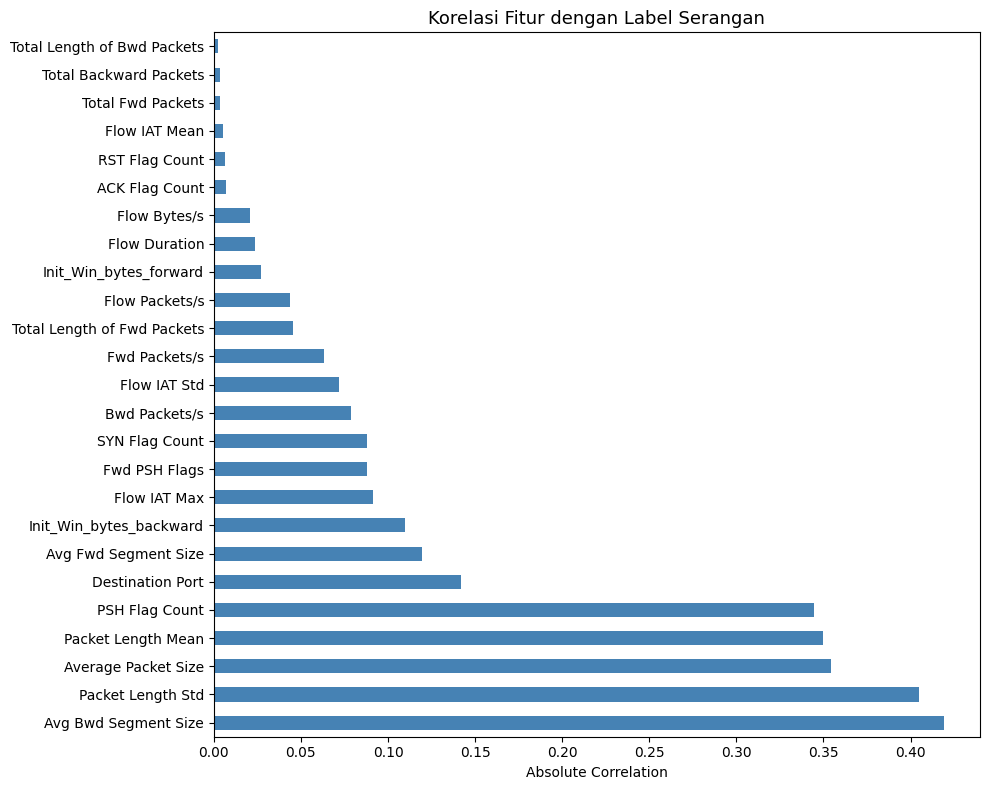


=== TOP 10 FITUR PALING BERPENGARUH ===
Avg Bwd Segment Size       0.418951
Packet Length Std          0.405147
Average Packet Size        0.354443
Packet Length Mean         0.349793
PSH Flag Count             0.344338
Destination Port           0.141632
Avg Fwd Segment Size       0.119311
Init_Win_bytes_backward    0.109738
Flow IAT Max               0.091311
Fwd PSH Flags              0.087804


In [10]:
# Hitung korelasi setiap fitur dengan label attack
correlations = X.corrwith(y).abs().sort_values(ascending=False)

plt.figure(figsize=(10, 8))
correlations.plot(kind='barh', color='steelblue')
plt.title('Korelasi Fitur dengan Label Serangan', fontsize=13)
plt.xlabel('Absolute Correlation')
plt.tight_layout()
plt.savefig('feature_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n=== TOP 10 FITUR PALING BERPENGARUH ===")
print(correlations.head(10).to_string())

In [11]:
from sklearn.model_selection import train_test_split

# Dataset 1.3 juta terlalu besar untuk training awal
# Ambil sample yang seimbang: 100k normal + semua attack
df_normal  = df_clean[df_clean['is_attack'] == 0].sample(n=100_000, random_state=42)
df_attack  = df_clean[df_clean['is_attack'] == 1]

df_sampled = pd.concat([df_normal, df_attack]).sample(frac=1, random_state=42)

X_sampled = df_sampled[available]
y_sampled = df_sampled['is_attack']

# Split: 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X_sampled, y_sampled, test_size=0.2, random_state=42, stratify=y_sampled
)

print(f"Training set : {X_train.shape[0]:,} rows")
print(f"Test set     : {X_test.shape[0]:,} rows")
print(f"\nDistribusi train:")
print(f"  Normal : {(y_train == 0).sum():,}")
print(f"  Attack : {(y_train == 1).sum():,}")
print(f"\nDistribusi test:")
print(f"  Normal : {(y_test == 0).sum():,}")
print(f"  Attack : {(y_test == 1).sum():,}")

Training set : 262,286 rows
Test set     : 65,572 rows

Distribusi train:
  Normal : 80,000
  Attack : 182,286

Distribusi test:
  Normal : 20,000
  Attack : 45,572


In [12]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("✅ Normalisasi selesai")
print(f"Mean sebelum scaling (kolom 0): {X_train.iloc[:,0].mean():.2f}")
print(f"Mean setelah scaling (kolom 0): {X_train_scaled[:,0].mean():.4f}")
print(f"Std setelah scaling  (kolom 0): {X_train_scaled[:,0].std():.4f}")

✅ Normalisasi selesai
Mean sebelum scaling (kolom 0): 5727.04
Mean setelah scaling (kolom 0): 0.0000
Std setelah scaling  (kolom 0): 1.0000


In [14]:
print("Training Isolation Forest...")
print("(Estimasi waktu: 30-60 detik)\n")

# contamination = perkiraan proporsi anomali di data
# Dataset kita: 227k attack dari 1.35M total ≈ 16%
# Tapi di sample kita lebih tinggi karena kita ambil semua attack
n_attack  = (y_train == 1).sum()
n_total   = len(y_train)
contamination = round(n_attack / n_total, 2)
print(f"Contamination rate: {contamination} ({n_attack:,} attack dari {n_total:,} total)")

iso_forest = IsolationForest(
    n_estimators=200,       # jumlah tree
    contamination=contamination,
    max_samples='auto',
    random_state=42,
    n_jobs=-1,              # pakai semua CPU core
    verbose=1,
)

iso_forest.fit(X_train_scaled)
print("\n✅ Training selesai!")

Training Isolation Forest...
(Estimasi waktu: 30-60 detik)

Contamination rate: 0.69 (182,286 attack dari 262,286 total)


InvalidParameterError: The 'contamination' parameter of IsolationForest must be a str among {'auto'} or a float in the range (0.0, 0.5]. Got np.float64(0.69) instead.

In [15]:
print("Evaluating model...")

# Prediksi: Isolation Forest output -1 (anomali) dan 1 (normal)
# Kita convert ke 0 (normal) dan 1 (attack)
y_pred_raw = iso_forest.predict(X_test_scaled)
y_pred     = (y_pred_raw == -1).astype(int)

# Anomaly scores (semakin negatif = semakin anomali)
anomaly_scores = iso_forest.decision_function(X_test_scaled)

print("\n=== CLASSIFICATION REPORT ===")
print(classification_report(y_test, y_pred, target_names=['Normal', 'Attack']))

f1  = f1_score(y_test, y_pred)
print(f"F1-Score  : {f1:.4f}")
print(f"F1-Score% : {f1*100:.2f}%")

Evaluating model...


NotFittedError: This IsolationForest instance is not fitted yet. Call 'fit' with appropriate arguments before using this estimator.

NameError: name 'y_pred' is not defined

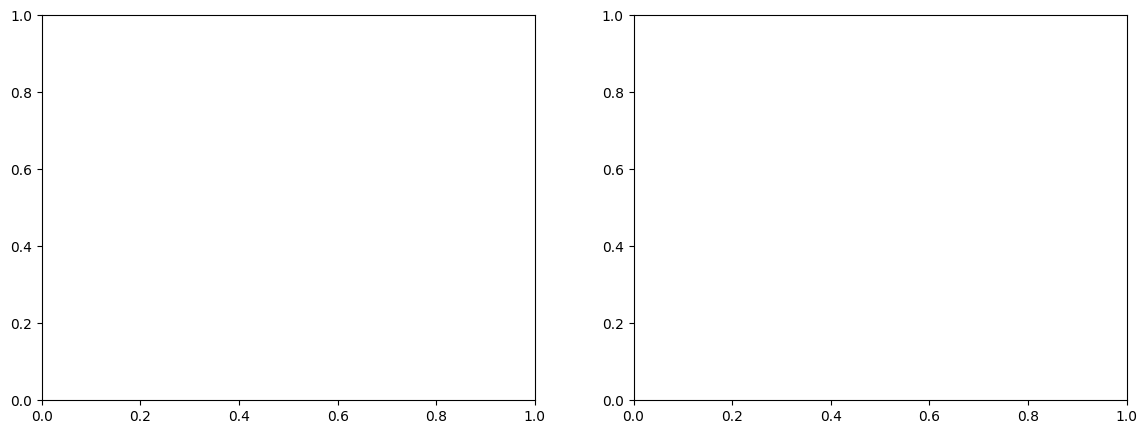

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt=',', cmap='Blues', ax=axes[0],
            xticklabels=['Normal','Attack'],
            yticklabels=['Normal','Attack'])
axes[0].set_title('Confusion Matrix', fontsize=13)
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

# Tambah anotasi
tn, fp, fn, tp = cm.ravel()
axes[0].set_xlabel(
    f'Predicted\n\nTP={tp:,} | FP={fp:,} | TN={tn:,} | FN={fn:,}', fontsize=10
)

# Plot 2: Anomaly Score Distribution
normal_scores = anomaly_scores[y_test == 0]
attack_scores = anomaly_scores[y_test == 1]

axes[1].hist(normal_scores, bins=60, alpha=0.6, color='#2ecc71', label='Normal', density=True)
axes[1].hist(attack_scores, bins=60, alpha=0.6, color='#e74c3c', label='Attack', density=True)
axes[1].axvline(x=0, color='black', linestyle='--', label='Threshold')
axes[1].set_title('Distribusi Anomaly Score', fontsize=13)
axes[1].set_xlabel('Anomaly Score (lebih negatif = lebih anomali)')
axes[1].set_ylabel('Density')
axes[1].legend()

plt.tight_layout()
plt.savefig('model_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n=== RINGKASAN HASIL ===")
print(f"True Positive  (attack terdeteksi)     : {tp:,}")
print(f"True Negative  (normal terdeteksi)     : {tn:,}")
print(f"False Positive (normal dikira attack)  : {fp:,}")
print(f"False Negative (attack tidak terdeteksi): {fn:,}")
print(f"\nF1-Score: {f1*100:.2f}%")